In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import KFold

from opfython.models import SupervisedOPF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from imblearn.under_sampling import NearMiss

from scipy.stats import wilcoxon
import scipy.stats as st

In [4]:
df = pd.read_excel('Online-Retail.xlsx')

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
df.shape

(541909, 8)

In [7]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

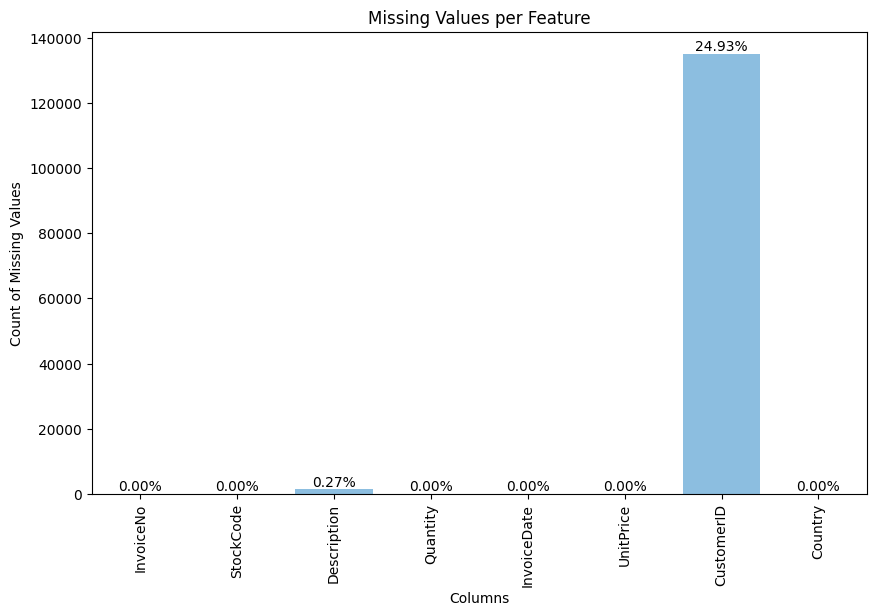

In [8]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_data = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percentage})

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data['Missing Count'], color='#7EC0EE')

for i, v in enumerate(missing_data['Missing Count']):
    plt.text(i, v + 1, f'{missing_data["Missing Percentage"].iloc[i]:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Missing Values per Feature')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=90)
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

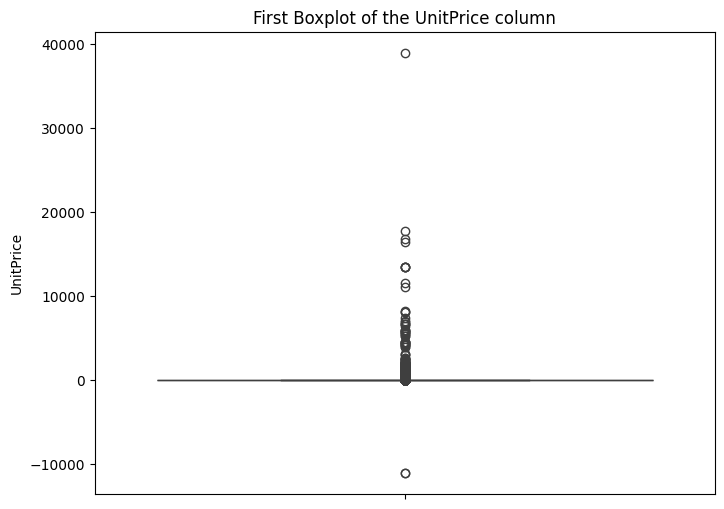

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='UnitPrice', data=df)
plt.title("First Boxplot of the UnitPrice column")
plt.show()

In [14]:
median = df['UnitPrice'][df['UnitPrice'] >= 0].median()
df['UnitPrice'] = df['UnitPrice'].apply(lambda x: median if x < 0 else x)

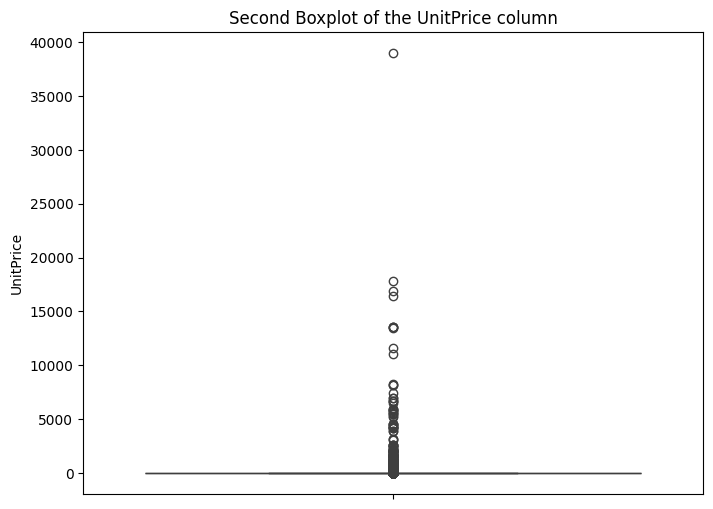

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='UnitPrice', data=df)
plt.title("Second Boxplot of the UnitPrice column")
plt.show()

In [16]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.651948
std          94.395273
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [17]:
Q1_UP = df['UnitPrice'].quantile(0.25)
Q2_UP = df['UnitPrice'].quantile(0.5)
Q3_UP = df['UnitPrice'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: UnitPrice")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: UnitPrice
- Q1: 1.25
- Q2 (Mediana): 2.08
- Q3: 4.13
- Limite Inferior: -3.07
- Limite Superior: 8.45


In [18]:
mean_UP = df['UnitPrice'].mean()
median_UP = df['UnitPrice'].median()
mode_UP = df['UnitPrice'].mode()[0]
var_UP = df['UnitPrice'].var()
std_UP = df['UnitPrice'].std()

print(f"Feature: UnitPrice")
print(f"- mean: {mean_UP:.6f}")
print(f"- median: {median_UP:.6f}")
print(f"- mode: {mode_UP:.6f}")
print(f"- var: {var_UP:.6f}")
print(f"- std: {std_UP:.6f}")

Feature: UnitPrice
- mean: 4.651948
- median: 2.080000
- mode: 1.250000
- var: 8910.467515
- std: 94.395273


In [19]:
df['Quantity'].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

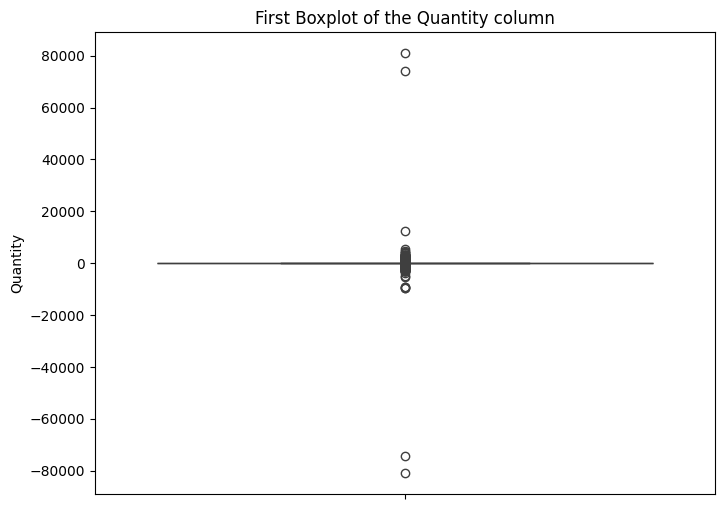

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Quantity', data=df)
plt.title("First Boxplot of the Quantity column")
plt.show()

In [21]:
median = df['Quantity'][df['Quantity'] > 0].median()
df['Quantity'] = df['Quantity'].apply(lambda x: median if x <= 0 else x)

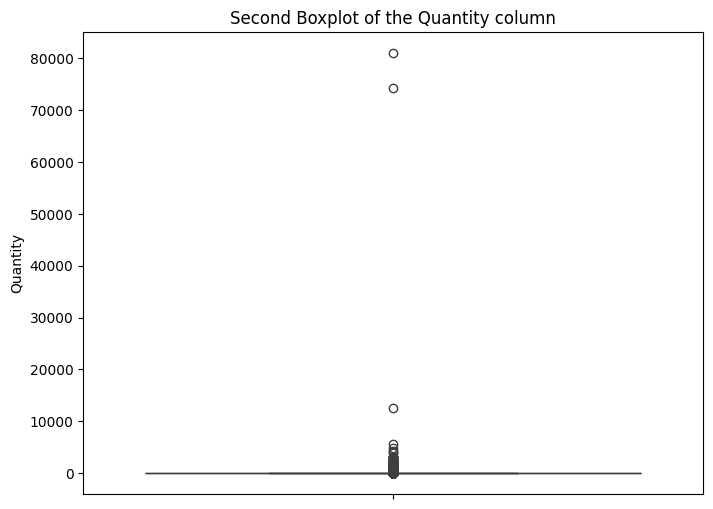

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Quantity', data=df)
plt.title("Second Boxplot of the Quantity column")
plt.show()

In [23]:
df['Quantity'].describe()

count    541909.000000
mean         10.505183
std         155.289026
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [24]:
Q1_Q = df['Quantity'].quantile(0.25)
Q2_Q = df['Quantity'].quantile(0.5)
Q3_Q = df['Quantity'].quantile(0.75)

lower_limit_Q = Q1_Q - 1.5 * (Q3_Q - Q1_Q)
upper_limit_Q = Q3_Q + 1.5 * (Q3_Q - Q1_Q)

print(f"Feature: Quantity")
print(f"- Q1: {Q1_Q:.2f}")
print(f"- Q2 (Mediana): {Q2_Q:.2f}")
print(f"- Q3: {Q3_Q:.2f}")
print(f"- Limite Inferior: {lower_limit_Q:.2f}")
print(f"- Limite Superior: {upper_limit_Q:.2f}")

Feature: Quantity
- Q1: 1.00
- Q2 (Mediana): 3.00
- Q3: 10.00
- Limite Inferior: -12.50
- Limite Superior: 23.50


In [25]:
mean_Q = df['Quantity'].mean()
median_Q = df['Quantity'].median()
mode_Q = df['Quantity'].mode()[0]
var_Q = df['Quantity'].var()
std_Q = df['Quantity'].std()

print(f"Feature: Quantity")
print(f"- mean: {mean_Q:.6f}")
print(f"- median: {median_Q:.6f}")
print(f"- mode: {mode_Q:.6f}")
print(f"- var: {var_Q:.6f}")
print(f"- std: {std_Q:.6f}")

Feature: Quantity
- mean: 10.505183
- median: 3.000000
- mode: 1.000000
- var: 24114.681744
- std: 155.289026


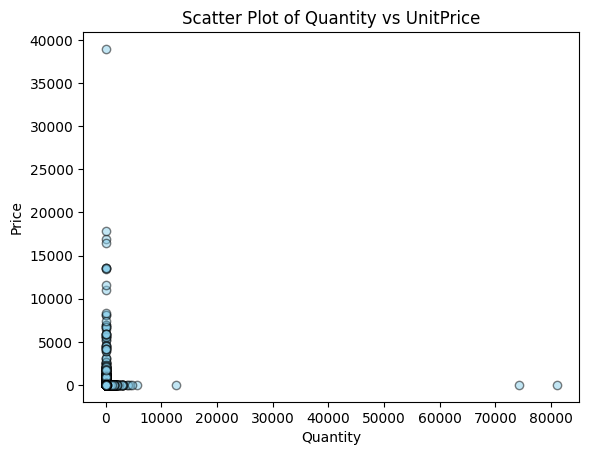

In [26]:
plt.scatter(df['Quantity'], df['UnitPrice'], color='skyblue', edgecolor='black', alpha=0.5)
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.show()

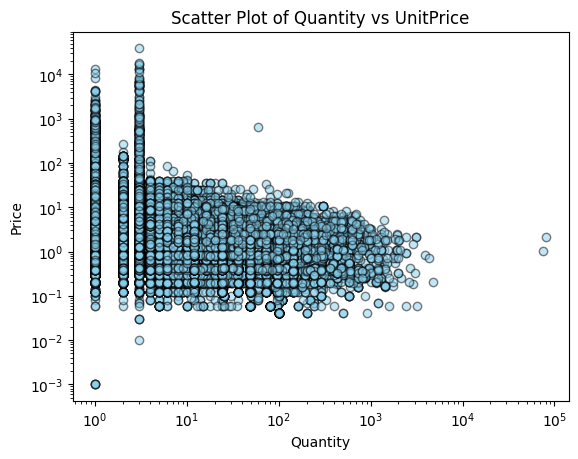

In [27]:
plt.scatter(df['Quantity'], df['UnitPrice'], color='skyblue', edgecolor='black', alpha=0.5)
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [28]:
df['Country'].describe()

count             541909
unique                38
top       United Kingdom
freq              495478
Name: Country, dtype: object

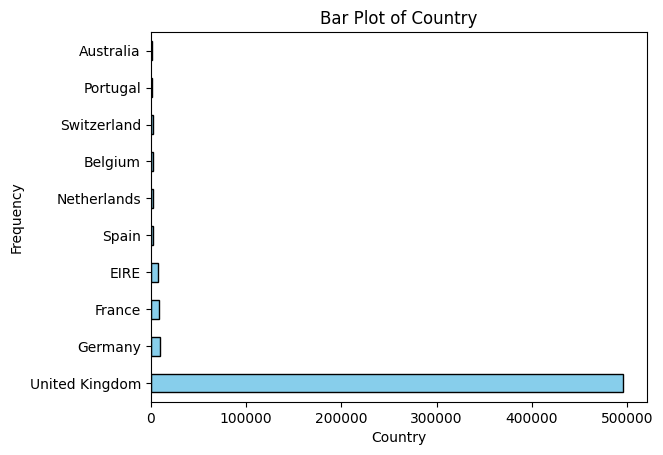

In [29]:
df['Country'].value_counts().head(10).plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Country')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.show()

In [30]:
df['InvoiceDate'].describe()

count                           541909
mean     2011-07-04 13:34:57.156386048
min                2010-12-01 08:26:00
25%                2011-03-28 11:34:00
50%                2011-07-19 17:17:00
75%                2011-10-19 11:27:00
max                2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

In [31]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')

df['Month'] = df['InvoiceDate'].dt.strftime('%m')
df['Week'] = df['InvoiceDate'].dt.strftime('%A')
df['Time'] = df['InvoiceDate'].dt.strftime('%H')

df = df.drop(columns=['InvoiceDate'])

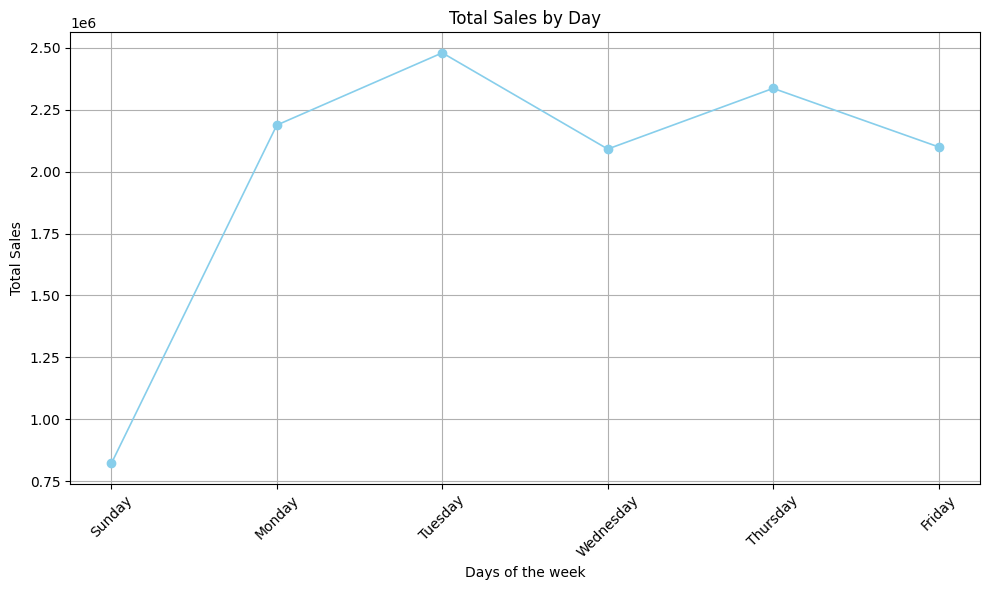

In [32]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
daywise = df.groupby('Week').agg({'TotalPrice': 'sum'}).reset_index()
df = df.drop(columns=['TotalPrice'])

daywise['Week'] = pd.Categorical(daywise['Week'], categories=["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"], ordered=True)
daywise = daywise.sort_values('Week')

plt.figure(figsize=(10, 6))
plt.plot(daywise['Week'], daywise['TotalPrice'], marker='o', color='skyblue', linewidth=1.2, markersize=6)
plt.title('Total Sales by Day')
plt.xlabel('Days of the week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

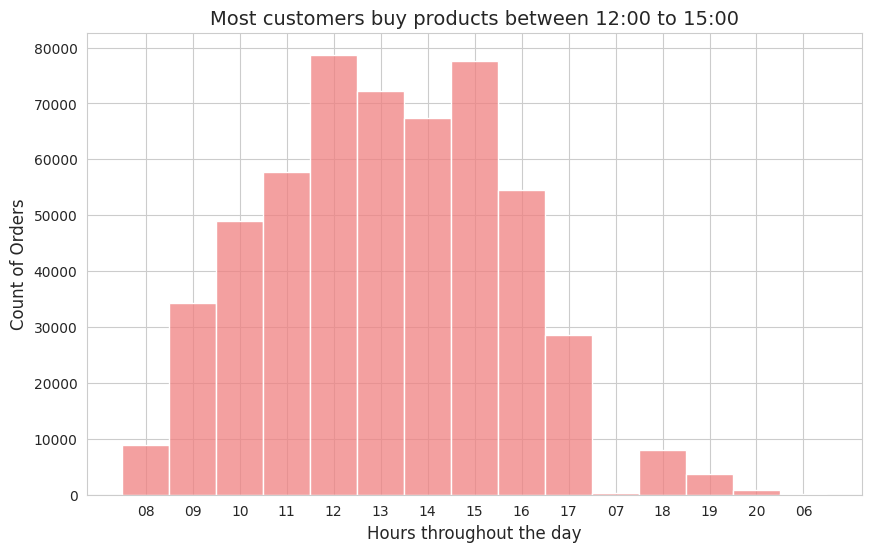

In [33]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', bins=24, color='lightcoral', kde=False)
plt.xlabel('Hours throughout the day', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.title('Most customers buy products between 12:00 to 15:00', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()

In [34]:
labels = [
    'January-February',
    'March-April',
    'May-June',
    'July-August',
    'September-October',
    'November-December'
]

df['Month'] = pd.cut(df['Month'].astype(int), bins=[0, 2, 4, 6, 8, 10, 12], labels=labels, right=True)

<Axes: title={'center': 'Months'}, ylabel='count'>

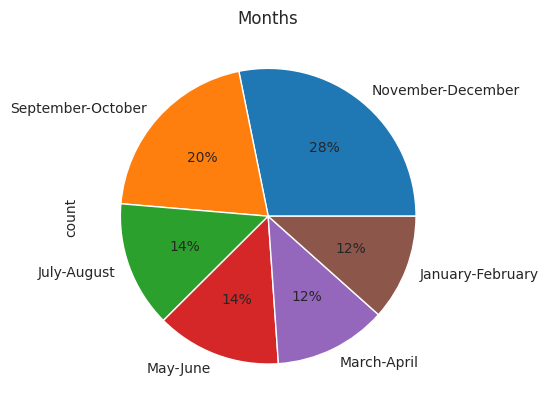

In [35]:
df['Month'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='Months')

In [36]:
labels_time = ['Midnight', 'Morning', 'Afternoon', 'Night']
df['Time'] = pd.cut(df['Time'].astype(int), bins=[-1, 5, 11, 17, 24], labels=labels_time, right=True)

<Axes: title={'center': 'Shifts'}, ylabel='count'>

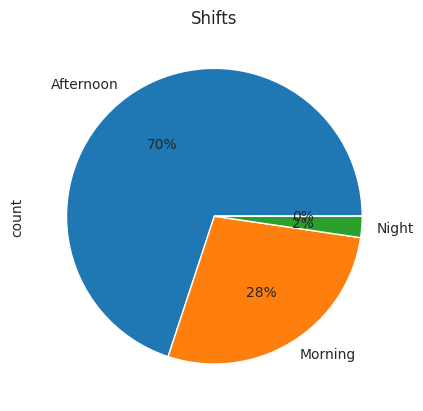

In [37]:
df['Time'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='Shifts')

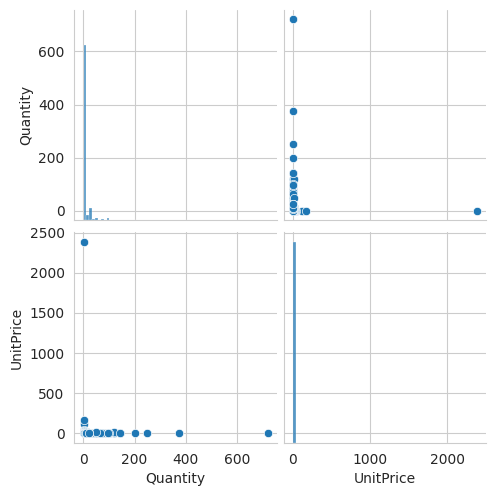

In [38]:
df_numeric = df[['Quantity', 'UnitPrice']]
sns.pairplot(df_numeric.sample(1000))
plt.show()

In [39]:
def categorize_price(price):
    if price <= Q1_UP:
        return "Low"
    elif price >= Q3_UP:
        return "High"
    else:
        return "Average"

df["PriceCategory"] = df["UnitPrice"].apply(categorize_price)

<Axes: title={'center': 'PriceCategory'}, ylabel='count'>

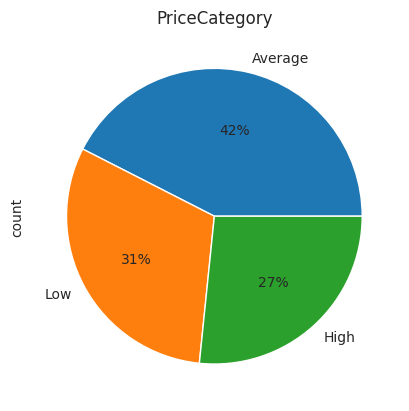

In [40]:
df['PriceCategory'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='PriceCategory')

In [41]:
df = pd.get_dummies(df, columns=['Country', 'Month', 'Week', 'Time'])
df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,PriceCategory,Country_Australia,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,Country_Channel Islands,Country_Cyprus,Country_Czech Republic,Country_Denmark,Country_EIRE,Country_European Community,Country_Finland,Country_France,Country_Germany,Country_Greece,Country_Hong Kong,Country_Iceland,Country_Israel,Country_Italy,Country_Japan,Country_Lebanon,Country_Lithuania,Country_Malta,Country_Netherlands,Country_Norway,Country_Poland,Country_Portugal,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Month_January-February,Month_March-April,Month_May-June,Month_July-August,Month_September-October,Month_November-December,Week_Friday,Week_Monday,Week_Sunday,Week_Thursday,Week_Tuesday,Week_Wednesday,Time_Midnight,Time_Morning,Time_Afternoon,Time_Night
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2.55,17850.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
1,536365,71053,WHITE METAL LANTERN,6.0,3.39,17850.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2.75,17850.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,3.39,17850.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,3.39,17850.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,0.85,12680.0,Low,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2.10,12680.0,Average,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False
541906,581587,23254,CHILDRENS 

In [42]:
x_temp = df.drop(['PriceCategory', 'InvoiceNo', 'CustomerID', 'Description', 'StockCode'], axis=1)

In [43]:
le = LabelEncoder()
y = le.fit_transform(df['PriceCategory'])
class_names = le.classes_
print(f"Classes: {class_names}")

Classes: ['Average' 'High' 'Low']


In [44]:
x = x_temp.drop(['UnitPrice'], axis=1)
x = x.values

<Axes: title={'center': 'PriceCategory'}, ylabel='count'>

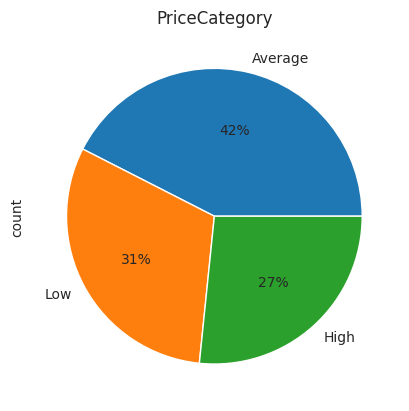

In [45]:
pd.Series(le.inverse_transform(y)).value_counts().plot(kind='pie', autopct='%1.0f%%', title='PriceCategory')

In [46]:
# df_res = pd.DataFrame(x_temp_res, columns=x_temp.columns)

In [47]:
df.shape

(541909, 61)

In [48]:
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(x)

In [49]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_escalonado)
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Classe_Alvo'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

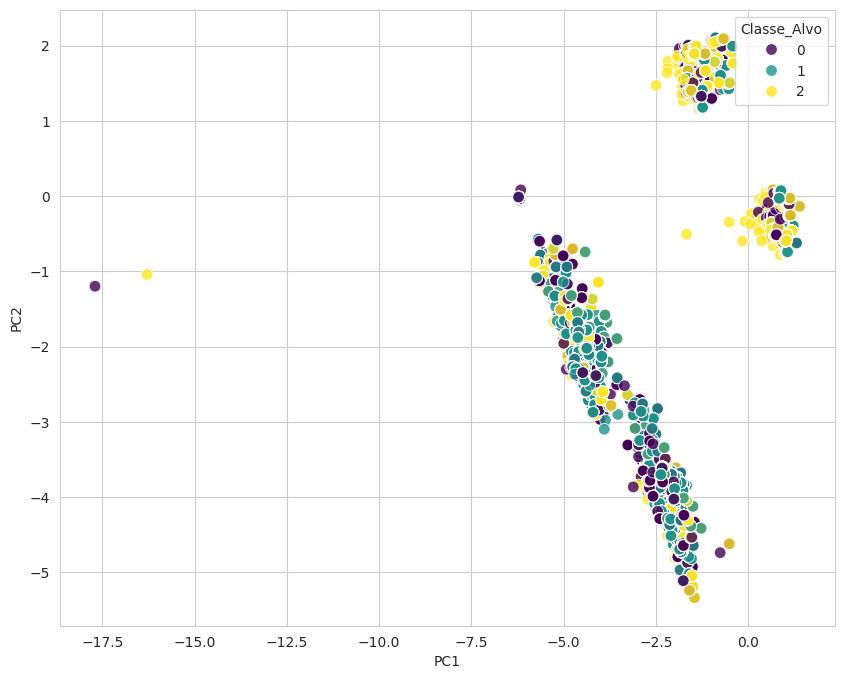

In [50]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis',
    data=df_pca, 
    alpha=0.8,
    s=70
)

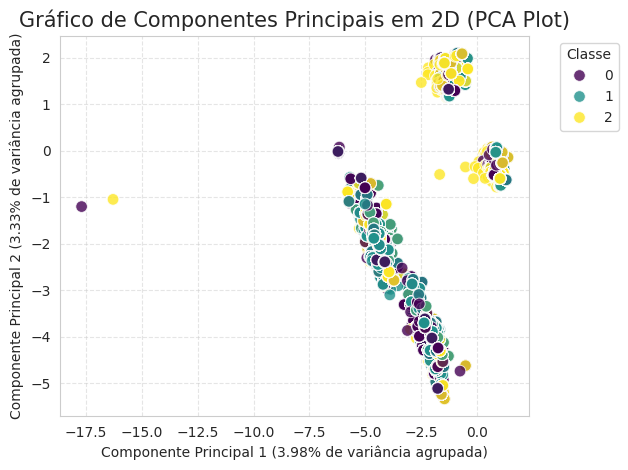

In [51]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

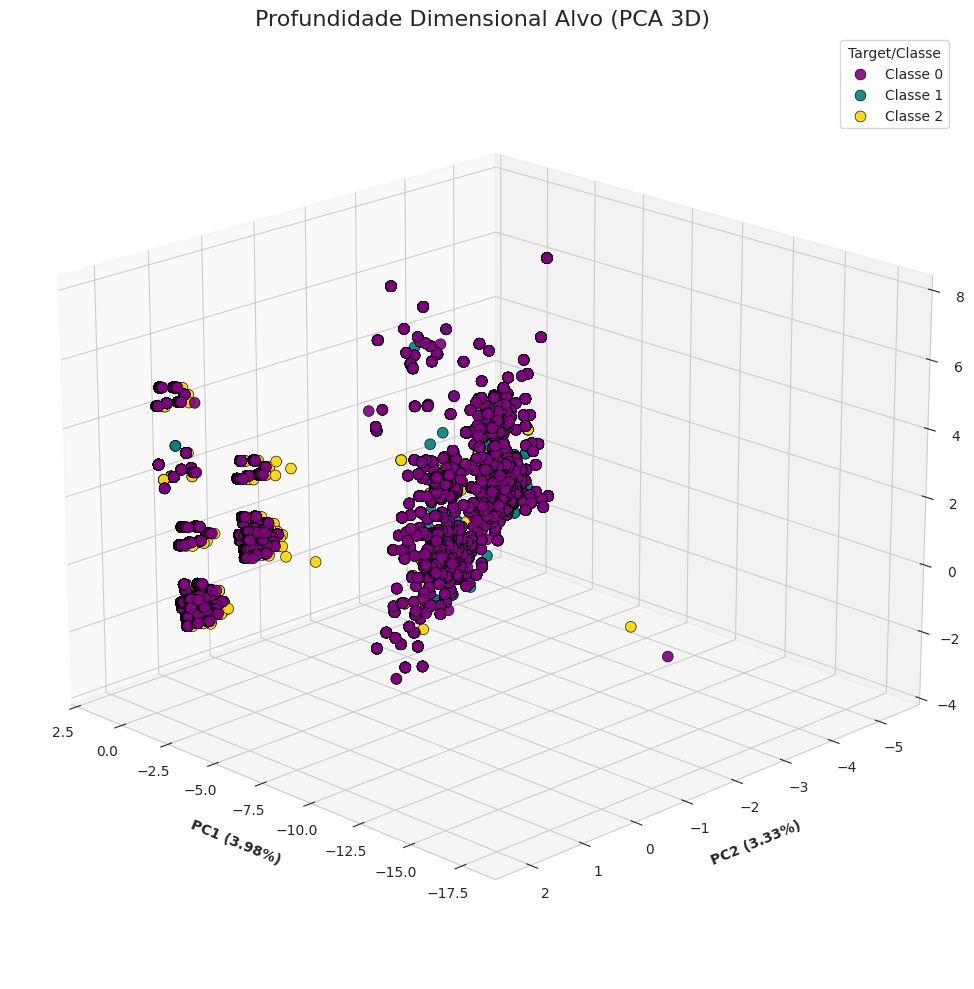

In [52]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_escalonado)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()

In [53]:
param_grid_KNN = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine']
}

In [54]:
param_grid_DT = {
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

In [55]:
param_grid_RF = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, 50]
}

In [56]:
param_grid_SVM = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1],
    'probability': [True]
}

In [57]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0],
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [58]:
param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],
     'solver': ['saga'],
     'penalty': ['l1', 'l2'],
}

In [59]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [60]:
param_grid_NB = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [61]:
param_grid_NC = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.5, 1.0]
}

In [62]:
param_grid_OPF = {
    'distance':['euclidean', 'squared_euclidean', 'log_squared_euclidean', 
                'manhattan', 'canberra', 'chebyshev']
}

In [63]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [64]:
S = MinMaxScaler()

In [65]:
test_scores_KNN = []
acc_test_scores_KNN = []
precision_test_scores_KNN = []
recall_test_scores_KNN = []
f1_test_scores_KNN = []
auroc_test_scores_KNN = []

test_scores_DT = []
acc_test_scores_DT = []
precision_test_scores_DT = []
recall_test_scores_DT = []
f1_test_scores_DT = []
auroc_test_scores_DT = []

test_scores_RF = []
acc_test_scores_RF = []
precision_test_scores_RF = []
recall_test_scores_RF = []
f1_test_scores_RF = []
auroc_test_scores_RF = []

test_scores_SVM = []
acc_test_scores_SVM = []
precision_test_scores_SVM = []
recall_test_scores_SVM = []
f1_test_scores_SVM = []
auroc_test_scores_SVM = []

test_scores_MLP = []
acc_test_scores_MLP = []
precision_test_scores_MLP = []
recall_test_scores_MLP = []
f1_test_scores_MLP = []
auroc_test_scores_MLP = []

test_scores_LR = []
acc_test_scores_LR = []
precision_test_scores_LR = []
recall_test_scores_LR = []
f1_test_scores_LR = []
auroc_test_scores_LR = []

test_scores_XGB = []
acc_test_scores_XGB = []
precision_test_scores_XGB = []
recall_test_scores_XGB = []
f1_test_scores_XGB = []
auroc_test_scores_XGB = []

test_scores_NB = []
acc_test_scores_NB = []
precision_test_scores_NB = []
recall_test_scores_NB = []
f1_test_scores_NB = []
auroc_test_scores_NB = []

test_scores_NC = []
acc_test_scores_NC = []
precision_test_scores_NC = []
recall_test_scores_NC = []
f1_test_scores_NC = []
auroc_test_scores_NC = []

test_scores_OPF = []
acc_test_scores_OPF = []
precision_test_scores_OPF = []
recall_test_scores_OPF = []
f1_test_scores_OPF = []
auroc_test_scores_OPF = []

In [66]:
confusion_matrices_KNN = []
confusion_matrices_DT = []
confusion_matrices_RF = []
confusion_matrices_SVM = []
confusion_matrices_MLP = []
confusion_matrices_LR = []
confusion_matrices_XGB = []
confusion_matrices_NB = []
confusion_matrices_NC = []
confusion_matrices_OPF = []

In [67]:
resultados_mdi = {
    'DT': [], 'RF': [], 'XGB': [], 'OPF': []
}

In [68]:
gridsearch_results_f1 = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [69]:
gridsearch_results_acc = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [70]:
# função de seleção f1_macro na validação interna
def validation_metric(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

In [ ]:
nm = NearMiss()

In [ ]:
def calcular_auroc(modelo, x_test_S, y_test, y_pred):
    try:
        y_proba = modelo.predict_proba(x_test_S)
        if y_proba.shape[1] == 2:
            return roc_auc_score(y_test, y_proba[:, 1])
        else:
            return roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except AttributeError:
        lb = LabelBinarizer()
        lb.fit(y_test)
        y_test_bin = lb.transform(y_test)
        y_pred_bin = lb.transform(y_pred)
        if y_test_bin.shape[1] == 1:
            return roc_auc_score(y_test, y_pred)
        else:
            return roc_auc_score(y_test_bin, y_pred_bin, average='weighted')

In [ ]:
for i, (train_index, test_index) in enumerate(kfold.split(x)):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    x_train_D, x_val, y_train_D, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

    params_KNN, f1_val_KNN, acc_val_KNN = [], [], []

    params_DT, f1_val_DT, acc_val_DT = [], [], []

    params_RF, f1_val_RF, acc_val_RF = [], [], []

    params_SVM, f1_val_SVM, acc_val_SVM = [], [], []

    params_MLP, f1_val_MLP, acc_val_MLP = [], [], []

    params_LR, f1_val_LR, acc_val_LR = [], [], []

    params_XGB, f1_val_XGB, acc_val_XGB = [], [], []

    params_NB, f1_val_NB, acc_val_NB = [], [], []

    params_NC, f1_val_NC, acc_val_NC = [], [], []

    params_OPF, f1_val_OPF, acc_val_OPF = [], [], []

    S.fit(x_train_D)
    x_train_D_S = S.transform(x_train_D)
    x_val_S = S.transform(x_val)

    x_train_D_resampled, y_train_D_resampled = nm.fit_resample(x_train_D_S, y_train_D)

    S.fit(x_train)
    x_train_S = S.transform(x_train)
    x_test_S = S.transform(x_test)

    x_train_resampled, y_train_resampled = nm.fit_resample(x_train_S, y_train)

    for params in ParameterGrid(param_grid_KNN):
        knn = KNeighborsClassifier(**params, n_jobs=-1)
        knn.fit(x_train_D_S, y_train_D_resampled)
        y_pred = knn.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_KNN.append(params)
        f1_val_KNN.append(f1)
        acc_val_KNN.append(acc)

    for params in ParameterGrid(param_grid_DT):
        dt = DecisionTreeClassifier(**params, random_state=42)
        dt.fit(x_train_D_S, y_train_D_resampled)
        y_pred = dt.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_DT.append(params)
        f1_val_DT.append(f1)
        acc_val_DT.append(acc)

    for params in ParameterGrid(param_grid_RF):
        rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        rf.fit(x_train_D_S, y_train_D_resampled)
        y_pred = rf.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_RF.append(params)
        f1_val_RF.append(f1)
        acc_val_RF.append(acc)

    for params in ParameterGrid(param_grid_SVM):
        svm = SupportVectorMachineClassifier(**params, random_state=42)
        svm.fit(x_train_D_S, y_train_D_resampled)
        y_pred = svm.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_SVM.append(params)
        f1_val_SVM.append(f1)
        acc_val_SVM.append(acc)

    for params in ParameterGrid(param_grid_MLP):
        mlp = MLPClassifier(**params)
        mlp.fit(x_train_D_S, y_train_D_resampled)
        y_pred = mlp.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_MLP.append(params)
        f1_val_MLP.append(f1)
        acc_val_MLP.append(acc)

    for params in ParameterGrid(param_grid_LR):
        lr = LogisticRegression(**params, max_iter=1000, random_state=42)
        lr.fit(x_train_D_S, y_train_D_resampled)
        y_pred = lr.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_LR.append(params)
        f1_val_LR.append(f1)
        acc_val_LR.append(acc)

    for params in ParameterGrid(param_grid_XGB):
        xgb = XGBClassifier(**params, random_state=42, device="cuda")
        xgb.fit(x_train_D_S, y_train_D_resampled)
        y_pred = xgb.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_XGB.append(params)
        f1_val_XGB.append(f1)
        acc_val_XGB.append(acc)

    for params in ParameterGrid(param_grid_NB):
        nb_model = GaussianNB(**params)
        nb_model.fit(x_train_D_S, y_train_D_resampled)
        y_pred = nb_model.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_NB.append(params)
        f1_val_NB.append(f1)
        acc_val_NB.append(acc)

    for params in ParameterGrid(param_grid_NC):
        nc = NearestCentroid(**params)
        nc.fit(x_train_D_S, y_train_D_resampled)
        y_pred = nc.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_NC.append(params)
        f1_val_NC.append(f1)
        acc_val_NC.append(acc)

    for params in ParameterGrid(param_grid_OPF):
        opf = SupervisedOPF(**params)
        opf.fit(np.array(x_train_D_S), np.array(y_train_D_resampled, dtype=np.int32))
        y_pred = opf.predict(np.array(x_val_S))
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='macro')
        params_OPF.append(params)
        f1_val_OPF.append(f1)
        acc_val_OPF.append(acc)

    print(f"Fold {i+1}:")

    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    best_params_DT  = params_DT[f1_val_DT.index(max(f1_val_DT))]
    best_params_RF  = params_RF[f1_val_RF.index(max(f1_val_RF))]
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    best_params_LR  = params_LR[f1_val_LR.index(max(f1_val_LR))]
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    best_params_NB  = params_NB[f1_val_NB.index(max(f1_val_NB))]
    best_params_NC  = params_NC[f1_val_NC.index(max(f1_val_NC))]
    best_params_OPF = params_OPF[f1_val_OPF.index(max(f1_val_OPF))]

    gridsearch_results_f1['KNN'].append(max(f1_val_KNN))
    gridsearch_results_acc['KNN'].append(max(acc_val_KNN))
    gridsearch_results_f1['DT'].append(max(f1_val_DT))
    gridsearch_results_acc['DT'].append(max(acc_val_DT))
    gridsearch_results_f1['RF'].append(max(f1_val_RF))
    gridsearch_results_acc['RF'].append(max(acc_val_RF))
    gridsearch_results_f1['SVM'].append(max(f1_val_SVM))
    gridsearch_results_acc['SVM'].append(max(acc_val_SVM))
    gridsearch_results_f1['MLP'].append(max(f1_val_MLP))
    gridsearch_results_acc['MLP'].append(max(acc_val_MLP))
    gridsearch_results_f1['LR'].append(max(f1_val_LR))
    gridsearch_results_acc['LR'].append(max(acc_val_LR))
    gridsearch_results_f1['XGB'].append(max(f1_val_XGB))
    gridsearch_results_acc['XGB'].append(max(acc_val_XGB))
    gridsearch_results_f1['NB'].append(max(f1_val_NB))
    gridsearch_results_acc['NB'].append(max(acc_val_NB))
    gridsearch_results_f1['NC'].append(max(f1_val_NC))
    gridsearch_results_acc['NC'].append(max(acc_val_NC))
    gridsearch_results_f1['OPF'].append(max(f1_val_OPF))
    gridsearch_results_acc['OPF'].append(max(acc_val_OPF))


    knn = KNeighborsClassifier(**best_params_KNN, n_jobs=-1)
    knn.fit(x_train_S, y_train_resampled)
    y_pred_knn = knn.predict(x_test_S)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_precision = precision_score(y_test, y_pred_knn, average='macro')
    knn_recall = recall_score(y_test, y_pred_knn, average='macro')
    knn_f1 = f1_score(y_test, y_pred_knn, average='macro')
    knn_auroc = calcular_auroc(knn, x_test_S, y_test, y_pred_knn)
    
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    confusion_matrices_KNN.append(cm_knn)

    acc_test_scores_KNN.append(knn_acc)
    precision_test_scores_KNN.append(knn_precision)
    recall_test_scores_KNN.append(knn_recall)
    f1_test_scores_KNN.append(knn_f1)
    auroc_test_scores_KNN.append(knn_auroc)

    print(f"\tKNeighborsClassifier:")
    print(f"\t- Melhores params: {best_params_KNN}")
    print(f"\t- Acurácia: {knn_acc:.4f} | Precision: {knn_precision:.4f} | Recall: {knn_recall:.4f} | F1: {knn_f1:.4f} | AUROC: {knn_auroc:.4f}")

    dt = DecisionTreeClassifier(**best_params_DT, random_state=42)
    dt.fit(x_train_S, y_train_resampled)
    y_pred_dt = dt.predict(x_test_S)
    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='macro')
    dt_recall = recall_score(y_test, y_pred_dt, average='macro')
    dt_f1 = f1_score(y_test, y_pred_dt, average='macro')
    dt_auroc = calcular_auroc(dt, x_test_S, y_test, y_pred_dt)

    resultados_mdi['DT'].append(dt.feature_importances_)

    cm_dt = confusion_matrix(y_test, y_pred_dt)
    confusion_matrices_DT.append(cm_dt)

    acc_test_scores_DT.append(dt_acc)
    precision_test_scores_DT.append(dt_precision)
    recall_test_scores_DT.append(dt_recall)
    f1_test_scores_DT.append(dt_f1)
    auroc_test_scores_DT.append(dt_auroc)

    print(f"\n\tDecisionTreeClassifier:")
    print(f"\t- Melhores params: {best_params_DT}")
    print(f"\t- Acurácia: {dt_acc:.4f} | Precision: {dt_precision:.4f} | Recall: {dt_recall:.4f} | F1: {dt_f1:.4f} | AUROC: {dt_auroc:.4f}")

    rf = RandomForestClassifier(**best_params_RF, random_state=42, n_jobs=-1)
    rf.fit(x_train_S, y_train_resampled)
    y_pred_rf = rf.predict(x_test_S)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='macro')
    rf_recall = recall_score(y_test, y_pred_rf, average='macro')
    rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
    rf_auroc = calcular_auroc(rf, x_test_S, y_test, y_pred_rf)

    resultados_mdi['RF'].append(rf.feature_importances_)

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    confusion_matrices_RF.append(cm_rf)

    acc_test_scores_RF.append(rf_acc)
    precision_test_scores_RF.append(rf_precision)
    recall_test_scores_RF.append(rf_recall)
    f1_test_scores_RF.append(rf_f1)
    auroc_test_scores_RF.append(rf_auroc)

    print(f"\n\tRandomForestClassifier:")
    print(f"\t- Melhores params: {best_params_RF}")
    print(f"\t- Acurácia: {rf_acc:.4f} | Precision: {rf_precision:.4f} | Recall: {rf_recall:.4f} | F1: {rf_f1:.4f} | AUROC: {rf_auroc:.4f}")

    svm = SupportVectorMachineClassifier(**best_params_SVM, random_state=42)
    svm.fit(x_train_S, y_train_resampled)
    y_pred_svm = svm.predict(x_test_S)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    svm_precision = precision_score(y_test, y_pred_svm, average='macro')
    svm_recall = recall_score(y_test, y_pred_svm, average='macro')
    svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
    svm_auroc = calcular_auroc(svm, x_test_S, y_test, y_pred_svm)

    cm_svm = confusion_matrix(y_test, y_pred_svm)
    confusion_matrices_SVM.append(cm_svm)

    acc_test_scores_SVM.append(svm_acc)
    precision_test_scores_SVM.append(svm_precision)
    recall_test_scores_SVM.append(svm_recall)
    f1_test_scores_SVM.append(svm_f1)
    auroc_test_scores_SVM.append(svm_auroc)

    print(f"\n\tSVM:")
    print(f"\t- Melhores params: {best_params_SVM}")
    print(f"\t- Acurácia: {svm_acc:.4f} | Precision: {svm_precision:.4f} | Recall: {svm_recall:.4f} | F1: {svm_f1:.4f} | AUROC: {svm_auroc:.4f}")

    mlp = MLPClassifier(**best_params_MLP)
    mlp.fit(x_train_S, y_train_resampled)
    y_pred_mlp = mlp.predict(x_test_S)
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    mlp_precision = precision_score(y_test, y_pred_mlp, average='macro')
    mlp_recall = recall_score(y_test, y_pred_mlp, average='macro')
    mlp_f1 = f1_score(y_test, y_pred_mlp, average='macro')
    mlp_auroc = calcular_auroc(mlp, x_test_S, y_test, y_pred_mlp)

    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    confusion_matrices_MLP.append(cm_mlp)

    acc_test_scores_MLP.append(mlp_acc)
    precision_test_scores_MLP.append(mlp_precision)
    recall_test_scores_MLP.append(mlp_recall)
    f1_test_scores_MLP.append(mlp_f1)
    auroc_test_scores_MLP.append(mlp_auroc)

    print(f"\n\tMLPClassifier:")
    print(f"\t- Melhores params: {best_params_MLP}")
    print(f"\t- Acurácia: {mlp_acc:.4f} | Precision: {mlp_precision:.4f} | Recall: {mlp_recall:.4f} | F1: {mlp_f1:.4f} | AUROC: {mlp_auroc:.4f}")

    lr = LogisticRegression(**best_params_LR, max_iter=1000, random_state=42)
    lr.fit(x_train_S, y_train_resampled)
    y_pred_lr = lr.predict(x_test_S)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='macro')
    lr_recall = recall_score(y_test, y_pred_lr, average='macro')
    lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
    lr_auroc = calcular_auroc(lr, x_test_S, y_test, y_pred_lr)

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    confusion_matrices_LR.append(cm_lr)

    acc_test_scores_LR.append(lr_acc)
    precision_test_scores_LR.append(lr_precision)
    recall_test_scores_LR.append(lr_recall)
    f1_test_scores_LR.append(lr_f1)
    auroc_test_scores_LR.append(lr_auroc)

    print(f"\n\tLogisticRegression:")
    print(f"\t- Melhores params: {best_params_LR}")
    print(f"\t- Acurácia: {lr_acc:.4f} | Precision: {lr_precision:.4f} | Recall: {lr_recall:.4f} | F1: {lr_f1:.4f} | AUROC: {lr_auroc:.4f}")

    xgb = XGBClassifier(**best_params_XGB, random_state=42, device="cuda")
    xgb.fit(x_train_S, y_train_resampled)
    y_pred_xgb = xgb.predict(x_test_S)
    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='macro')
    xgb_recall = recall_score(y_test, y_pred_xgb, average='macro')
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
    xgb_auroc = calcular_auroc(xgb, x_test_S, y_test, y_pred_xgb)

    resultados_mdi['XGB'].append(xgb.feature_importances_)

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    confusion_matrices_XGB.append(cm_xgb)

    acc_test_scores_XGB.append(xgb_acc)
    precision_test_scores_XGB.append(xgb_precision)
    recall_test_scores_XGB.append(xgb_recall)
    f1_test_scores_XGB.append(xgb_f1)
    auroc_test_scores_XGB.append(xgb_auroc)

    print(f"\n\tXGBClassifier:")
    print(f"\t- Melhores params: {best_params_XGB}")
    print(f"\t- Acurácia: {xgb_acc:.4f} | Precision: {xgb_precision:.4f} | Recall: {xgb_recall:.4f} | F1: {xgb_f1:.4f} | AUROC: {xgb_auroc:.4f}")

    nb_model = GaussianNB(**best_params_NB)
    nb_model.fit(x_train_S, y_train_resampled)
    y_pred_nb = nb_model.predict(x_test_S)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    nb_precision = precision_score(y_test, y_pred_nb, average='macro')
    nb_recall = recall_score(y_test, y_pred_nb, average='macro')
    nb_f1 = f1_score(y_test, y_pred_nb, average='macro')
    nb_auroc = calcular_auroc(nb_model, x_test_S, y_test, y_pred_nb)

    cm_nb = confusion_matrix(y_test, y_pred_nb)
    confusion_matrices_NB.append(cm_nb)

    acc_test_scores_NB.append(nb_acc)
    precision_test_scores_NB.append(nb_precision)
    recall_test_scores_NB.append(nb_recall)
    f1_test_scores_NB.append(nb_f1)
    auroc_test_scores_NB.append(nb_auroc)

    print(f"\n\tGaussianNB:")
    print(f"\t- Melhores params: {best_params_NB}")
    print(f"\t- Acurácia: {nb_acc:.4f} | Precision: {nb_precision:.4f} | Recall: {nb_recall:.4f} | F1: {nb_f1:.4f} | AUROC: {nb_auroc:.4f}")

    nc = NearestCentroid(**best_params_NC)
    nc.fit(x_train_S, y_train_resampled)
    y_pred_nc = nc.predict(x_test_S)
    nc_acc = accuracy_score(y_test, y_pred_nc)
    nc_precision = precision_score(y_test, y_pred_nc, average='macro')
    nc_recall = recall_score(y_test, y_pred_nc, average='macro')
    nc_f1 = f1_score(y_test, y_pred_nc, average='macro')
    nc_auroc = calcular_auroc(nc, x_test_S, y_test, y_pred_nc)

    cm_nc = confusion_matrix(y_test, y_pred_nc)
    confusion_matrices_NC.append(cm_nc)

    acc_test_scores_NC.append(nc_acc)
    precision_test_scores_NC.append(nc_precision)
    recall_test_scores_NC.append(nc_recall)
    f1_test_scores_NC.append(nc_f1)
    auroc_test_scores_NC.append(nc_auroc)

    print(f"\n\tNearestCentroid:")
    print(f"\t- Melhores params: {best_params_NC}")
    print(f"\t- Acurácia: {nc_acc:.4f} | Precision: {nc_precision:.4f} | Recall: {nc_recall:.4f} | F1: {nc_f1:.4f} | AUROC: {nc_auroc:.4f}")

    opf = SupervisedOPF(**best_params_OPF)
    opf.fit(np.array(x_train_S), np.array(y_train_resampled, dtype=np.int32))
    y_pred_opf = opf.predict(np.array(x_test_S))
    opf_acc = accuracy_score(y_test, y_pred_opf)
    opf_precision = precision_score(y_test, y_pred_opf, average='macro')
    opf_recall = recall_score(y_test, y_pred_opf, average='macro')
    opf_f1 = f1_score(y_test, y_pred_opf, average='macro')
    opf_auroc = calcular_auroc(opf, x_test_S, y_test, y_pred_opf)
    
    cm_opf = confusion_matrix(y_test, y_pred_opf)
    confusion_matrices_OPF.append(cm_opf)

    acc_test_scores_OPF.append(opf_acc)
    precision_test_scores_OPF.append(opf_precision)
    recall_test_scores_OPF.append(opf_recall)
    f1_test_scores_OPF.append(opf_f1)
    auroc_test_scores_OPF.append(opf_auroc)

    print(f"\n\tSupervisedOPF:")
    print(f"\t- Melhores params: {best_params_OPF}")
    print(f"\t- Acurácia: {opf_acc:.4f} | Precision: {opf_precision:.4f} | Recall: {opf_recall:.4f} | F1: {opf_f1:.4f} | AUROC: {opf_auroc:.4f}")

    print("----------------------------------------")


In [ ]:
df_gs_acc = pd.DataFrame(gridsearch_results_acc, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_acc['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs_acc.columns:
    axes[0].plot(df_gs_acc.index, df_gs_acc[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor Acurácia de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs_acc.mean()
stds = df_gs_acc.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std da Acurácia (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Accuracy Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
df_gs = pd.DataFrame(gridsearch_results_f1, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_f1['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs.columns:
    axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor F1 de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs.mean()
stds = df_gs.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std do F1 (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('F1 Score Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 16))  # altura maior para 3 linhas
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'MLP', 'Logistic Regression', 'XGBoost', 'GaussianNB', 'NearestCentroid', 'SupervisedOPF']
confusion_matrices = [cm_knn, cm_dt, cm_rf, cm_svm, cm_mlp, cm_lr, cm_xgb, cm_nb, cm_nc, cm_opf]
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Greys', 'YlOrBr', 'YlGnBu', 'BuPu', 'YlOrRd']

class_labels = [' 0-1 Visita ', ' 2+ Visitas ']

for j, (model, cm, color) in enumerate(zip(models, confusion_matrices, colors)):
    plt.subplot(3, 4, j+1)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=color, ax=plt.gca(), values_format='d')

    plt.title(f'{model}', fontsize=12, fontweight='bold')
    plt.xlabel('Predição', fontsize=9)
    plt.ylabel('Real', fontsize=9)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle(f'Matrizes de Confusão - Visitas Médicas (Fold {i+1})',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [ ]:
all_metrics_results = {
    'Acurácia': [
        ('KNeighborsClassifier', acc_test_scores_KNN),
        ('DecisionTreeClassifier', acc_test_scores_DT),
        ('RandomForestClassifier', acc_test_scores_RF),
        ('SVM', acc_test_scores_SVM),
        ('MLPClassifier', acc_test_scores_MLP),
        ('LogisticRegression', acc_test_scores_LR),
        ('XGBClassifier', acc_test_scores_XGB),
        ('GaussianNB', acc_test_scores_NB),
        ('NearestCentroid', acc_test_scores_NC),
        ('SupervisedOPF', acc_test_scores_OPF)
         
    ],
    'Precisão': [
        ('KNeighborsClassifier', precision_test_scores_KNN),
        ('DecisionTreeClassifier', precision_test_scores_DT),
        ('RandomForestClassifier', precision_test_scores_RF),
        ('SVM', precision_test_scores_SVM),
        ('MLPClassifier', precision_test_scores_MLP),
        ('LogisticRegression', precision_test_scores_LR),
        ('XGBClassifier', precision_test_scores_XGB),
        ('GaussianNB', precision_test_scores_NB),
        ('NearestCentroid', precision_test_scores_NC),
        ('SupervisedOPF', precision_test_scores_OPF)

    ],
    'Recall': [
        ('KNeighborsClassifier', recall_test_scores_KNN),
        ('DecisionTreeClassifier', recall_test_scores_DT),
        ('RandomForestClassifier', recall_test_scores_RF),
        ('SVM', recall_test_scores_SVM),
        ('MLPClassifier', recall_test_scores_MLP),
        ('LogisticRegression', recall_test_scores_LR),
        ('XGBClassifier', recall_test_scores_XGB),
        ('GaussianNB', recall_test_scores_NB),
        ('NearestCentroid', recall_test_scores_NC),
        ('SupervisedOPF', recall_test_scores_OPF)

    ],
    'F1-Score': [
        ('KNeighborsClassifier', f1_test_scores_KNN),
        ('DecisionTreeClassifier', f1_test_scores_DT),
        ('RandomForestClassifier', f1_test_scores_RF),
        ('SVM', f1_test_scores_SVM),
        ('MLPClassifier', f1_test_scores_MLP),
        ('LogisticRegression', f1_test_scores_LR),
        ('XGBClassifier', f1_test_scores_XGB),
        ('GaussianNB', f1_test_scores_NB),
        ('NearestCentroid', f1_test_scores_NC),
        ('SupervisedOPF', f1_test_scores_OPF)
    ],
    'AUROC': [
        ('KNeighborsClassifier', auroc_test_scores_KNN),
        ('DecisionTreeClassifier', auroc_test_scores_DT),
        ('RandomForestClassifier', auroc_test_scores_RF),
        ('SVM', auroc_test_scores_SVM),
        ('MLPClassifier', auroc_test_scores_MLP),
        ('LogisticRegression', auroc_test_scores_LR),
        ('XGBClassifier', auroc_test_scores_XGB),
        ('GaussianNB', auroc_test_scores_NB),
        ('NearestCentroid', auroc_test_scores_NC),
        ('SupervisedOPF', auroc_test_scores_OPF)
    ]
}

alpha = 0.05

for metric_name, model_scores_list in all_metrics_results.items():

    for i in range(len(model_scores_list)):
        for j in range(i + 1, len(model_scores_list)):
            model1_name, scores1 = model_scores_list[i]
            model2_name, scores2 = model_scores_list[j]

            print(f"\nComparando {model1_name} x {model2_name}:")

            if len(scores1) != len(scores2):
                print(f"\t- ERRO: Tamanhos das listas de scores são diferentes.")
                continue
            if len(scores1) < 2:
                print("\t- ERRO: Não há scores suficientes para o teste.")
                continue

            try:
                stat, p_val = wilcoxon(scores1, scores2, zero_method='zsplit', correction=False)
            except ValueError as e:
                print(f"\t- AVISO: Teste de Wilcoxon não pôde ser calculado. ({e})")
                mean1 = np.mean(scores1)
                mean2 = np.mean(scores2)
                print(f"\t- Média {model1_name}: {mean1:.4f}")
                print(f"\t- Média {model2_name}: {mean2:.4f}")
                print("\t-> Sem conclusão estatística.")
                print("----------------------------------------")
                continue

            mean1 = np.mean(scores1)
            mean2 = np.mean(scores2)

            print(f"\t- Amostras (n): {len(scores1)}")
            print(f"\t- Média {model1_name}: {mean1:.4f}")
            print(f"\t- Média {model2_name}: {mean2:.4f}")
            print(f"\t- Estatística Z: {stat:.4f}")
            print(f"\t- Valor-p (p-value): {p_val:.4f}")

            if p_val < alpha:
                print(f"\t-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha}).")
                best_model = model1_name if mean1 > mean2 else model2_name
                print(f"\t-> Melhor modelo (pela média): {best_model}")
            else:
                print(f"\t-> Resultado: Sem diferença estatisticamente significativa (p >= {alpha}).")

            print("----------------------------------------")

In [ ]:
print("\nRESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO")

algorithms = {
    'KNeighborsClassifier':  (acc_test_scores_KNN, f1_test_scores_KNN, precision_test_scores_KNN, recall_test_scores_KNN, auroc_test_scores_KNN),
    'DecisionTreeClassifier':(acc_test_scores_DT,  f1_test_scores_DT,  precision_test_scores_DT,  recall_test_scores_DT,  auroc_test_scores_DT),
    'RandomForestClassifier':(acc_test_scores_RF,  f1_test_scores_RF,  precision_test_scores_RF,  recall_test_scores_RF,  auroc_test_scores_RF),
    'SVM':                   (acc_test_scores_SVM, f1_test_scores_SVM, precision_test_scores_SVM, recall_test_scores_SVM, auroc_test_scores_SVM),
    'MLPClassifier':         (acc_test_scores_MLP, f1_test_scores_MLP, precision_test_scores_MLP, recall_test_scores_MLP, auroc_test_scores_MLP),
    'LogisticRegression':    (acc_test_scores_LR,  f1_test_scores_LR,  precision_test_scores_LR,  recall_test_scores_LR,  auroc_test_scores_LR),
    'XGBClassifier':         (acc_test_scores_XGB, f1_test_scores_XGB, precision_test_scores_XGB, recall_test_scores_XGB, auroc_test_scores_XGB),
    'GaussianNB':           (acc_test_scores_NB,  f1_test_scores_NB,  precision_test_scores_NB,  recall_test_scores_NB,  auroc_test_scores_NB),
    'NearestCentroid':      (acc_test_scores_NC,  f1_test_scores_NC,  precision_test_scores_NC,  recall_test_scores_NC,  auroc_test_scores_NC),
    'SupervisedOPF':        (acc_test_scores_OPF, f1_test_scores_OPF, precision_test_scores_OPF, recall_test_scores_OPF, auroc_test_scores_OPF)
}

for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    print(f"\n{name}:")
    print(f"  Acurácia : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  F1       : {np.mean(f1):.4f} ± {np.std(f1):.4f}")
    print(f"  Precision: {np.mean(precision):.4f} ± {np.std(precision):.4f}")
    print(f"  Recall   : {np.mean(recall):.4f} ± {np.std(recall):.4f}")
    print(f"  AUROC    : {np.mean(auroc):.4f} ± {np.std(auroc):.4f}")